# Práctica de Laboratorio
AES y Modos de Operación sobre Imágenes BMP
Dra. Vanessa Miranda
Marzo 2026

## Objetivo
Comprender de forma visual y práctica cómo funcionan los modos de operación ECB, CBC y CTR al aplicarse sobre una imagen BMP, cómo se recupera la imagen mediante el proceso de descifrado con la llave correcta, qué sucede cuando se altera un byte del archivo cifrado y por qué la llave correcta es indispensable para recuperar la información.

## Competencias a desarrollar
- Identificar diferencias visuales entre ECB, CBC y CTR.
- Generar material criptográfico realista usando un generador aleatorio.
- Guardar y reutilizar llaves y parámetros criptográficos.
- Cifrar y descifrar imágenes BMP con AES.
- Analizar el efecto de modificar un byte del archivo cifrado.
- Verificar experimentalmente que solo la llave correcta permite recuperar la imagen.

## Material requerido
- Python 3 instalado.
- Una imagen en formato .bmp.
- Las librerías pycryptodome y pillow.


## Parte 0. Instalación de librerías
Ejecutar en terminal:
pip install pycryptodome pillow

Verificar:
from Crypto.Cipher import AES
from Crypto.Random import get_random_bytes
import json

## Parte 1. Preparación del archivo de trabajo
Convertir la imagen a formato BMP si actualmente está en JPG o PNG.
El archivo de entrada deberá llamarse: input.bmp

## Parte 2. Código base

In [1]:
%pip install pycryptodome pillow opencv-python matplotlib

from Crypto.Cipher import AES
from Crypto.Random import get_random_bytes
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt

Note: you may need to restart the kernel to use updated packages.


In [2]:
def pad(data, block_size=16):
    pad_len = block_size - (len(data) % block_size)
    return data + bytes([pad_len]) * pad_len

def read_bmp(file_path):
    with open(file_path, 'rb') as f:
        bmp = f.read()
    return bmp[:54], bmp[54:]

def write_bmp(file_path, header, body):
    with open(file_path, 'wb') as f:
        f.write(header + body)

In [3]:
def show_image(file_path, title="Imagen"):
    img = cv2.imread(file_path)

    if img is None:
        print(f"No se pudo abrir {file_path}")
        return

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img_rgb)
    plt.title(title)
    plt.axis('off')
    plt.show()

### 2.2 Generación y guardado de material criptográfico

In [4]:
def generate_crypto_material():
    return {
        'key': get_random_bytes(16).hex(),
        'iv': get_random_bytes(16).hex(),
        'nonce': get_random_bytes(8).hex()
    }

def save_crypto_material(material, file):
    with open(file, 'w') as f:
        json.dump(material, f, indent=4)

def load_crypto_material(file):
    with open(file, 'r') as f:
        return json.load(f)

### 2.3 Generar y guardar llaves

In [5]:
material = generate_crypto_material()
save_crypto_material(material, 'mis_claves_35967.json')
print(material)

{'key': 'f54cf55cf654cee0744392498d7e91a6', 'iv': '6cf2253e00d736ce1d0949dc20615e74', 'nonce': 'c2f79429077d8ccf'}


## Parte 3. Cifrado de la imagen

In [6]:
def encrypt_bmp(input_file, output_file, mode, material):
    header, body = read_bmp(input_file)
    key = bytes.fromhex(material['key'])

    if mode == 'ECB':
        cipher = AES.new(key, AES.MODE_ECB)
        enc = cipher.encrypt(pad(body))[:len(body)]
    elif mode == 'CBC':
        iv = bytes.fromhex(material['iv'])
        cipher = AES.new(key, AES.MODE_CBC, iv=iv)
        enc = cipher.encrypt(pad(body))[:len(body)]
    elif mode == 'CTR':
        nonce = bytes.fromhex(material['nonce'])
        cipher = AES.new(key, AES.MODE_CTR, nonce=nonce)
        enc = cipher.encrypt(body)
    else:
        raise ValueError('Modo no soportado')

    write_bmp(output_file, header, enc)

### 3.2 Cifrar la imagen en los tres modos

In [7]:
material = load_crypto_material('mis_claves_35967.json')
encrypt_bmp('input.bmp','ecb.bmp','ECB',material)
encrypt_bmp('input.bmp','cbc.bmp','CBC',material)
encrypt_bmp('input.bmp','ctr.bmp','CTR',material)

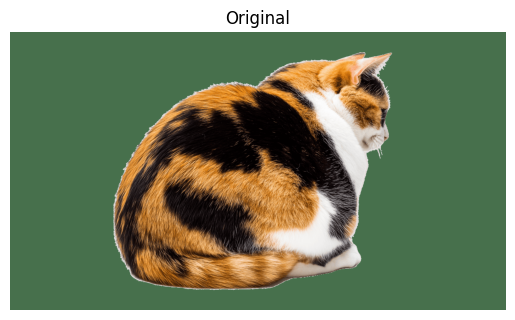

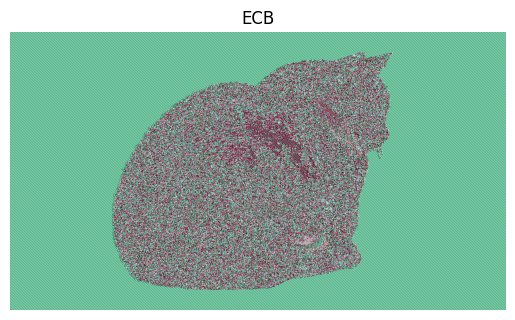

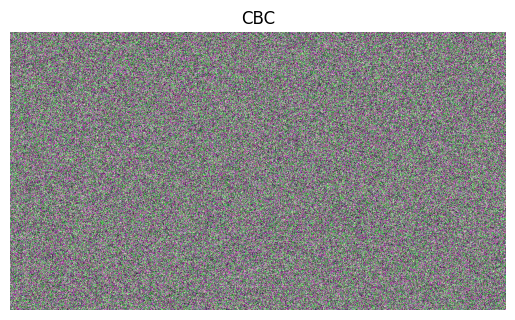

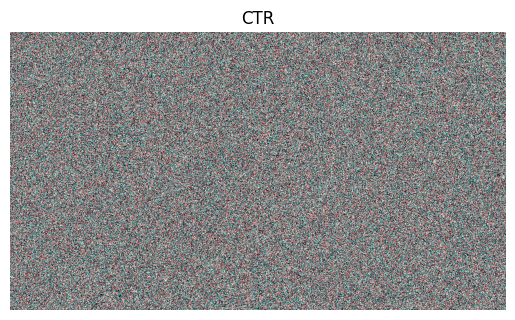

In [8]:
# Visualización de imágenes cifradas
show_image('input.bmp', 'Original')
show_image('ecb.bmp', 'ECB')
show_image('cbc.bmp', 'CBC')
show_image('ctr.bmp', 'CTR')

### 3.3 Observación visual
Abrir los tres archivos generados:
ecb.bmp
cbc.bmp
ctr.bmp
y compáralos con la imagen original.

Preguntas de observación:
1. Cuál de los tres modos deja ver más estructura de la imagen original?

El modo que deja ver más de la imagen original es el modo ECB, puesto que si bien se muestra como estática, el fondo contrasta completamente y se mantiene la silueta del gato. Además, puedo distinguir perfectamente una de sus manchas más prominentes en ello. Entonces, creo que sería el que no utilizaría.

2. Cuál parece producir una salida más cercana a ruido aleatorio?

Pues, creo que me decantaría por CTR.

3. Qué sugiere esto acerca de la seguridad de ECB frente a CBC y CTR?

Yo creo que ECB no ofusca lo suficiente la información pese a tener las mismas llaves y que se pueden realizar inferencias muy fuertes sobre la información aparentemente cifrada.

## Parte 4 Descifrado

In [9]:
def decrypt_bmp(input_file, output_file, mode, material):
    header, body = read_bmp(input_file)
    key = bytes.fromhex(material['key'])

    if mode == 'ECB':
        cipher = AES.new(key, AES.MODE_ECB)
        dec = cipher.decrypt(pad(body))[:len(body)]
    elif mode == 'CBC':
        iv = bytes.fromhex(material['iv'])
        cipher = AES.new(key, AES.MODE_CBC, iv=iv)
        dec = cipher.decrypt(pad(body))[:len(body)]
    elif mode == 'CTR':
        nonce = bytes.fromhex(material['nonce'])
        cipher = AES.new(key, AES.MODE_CTR, nonce=nonce)
        dec = cipher.decrypt(body)

    write_bmp(output_file, header, dec)

## Parte 4.2 Descifrar los archivos generados

In [10]:
material = load_crypto_material('mis_claves_35967.json')
decrypt_bmp('ecb.bmp','ecb_descifrada.bmp','ECB',material)
decrypt_bmp('cbc.bmp','cbc_descifrada.bmp','CBC',material)
decrypt_bmp('ctr.bmp','ctr_descifrada.bmp','CTR',material)

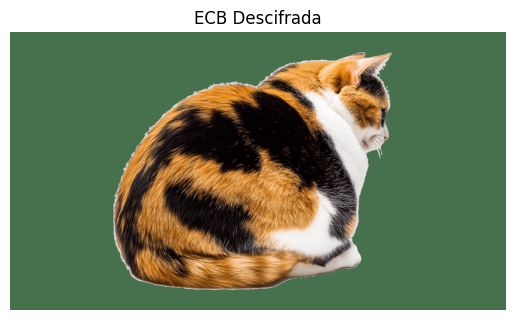

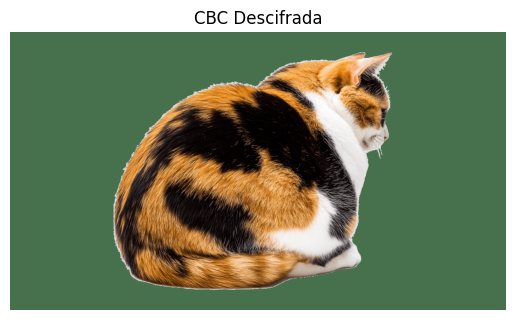

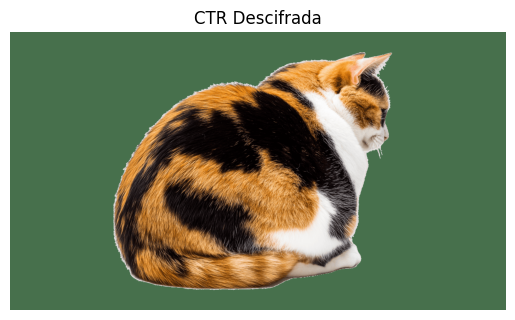

In [11]:
# Visualización de imágenes descifradas
show_image('ecb_descifrada.bmp', 'ECB Descifrada')
show_image('cbc_descifrada.bmp', 'CBC Descifrada')
show_image('ctr_descifrada.bmp', 'CTR Descifrada')

### 4.3 Verificación
Abrir las imágenes descifradas y compáralas con la original.

Preguntas:

4. Las imágenes descifradas coinciden visualmente con la original?

Sí, las imágenes descifradas coinciden con la forma y el color y todo. Es el mismo gato, está bien bonito ese gato y es el mismo. Yo me identifico con ese gato, profe.

5. Por qué fue posible recuperar la imagen?

Porque utilizamos la misma llave y tenemos conocimiento pleno del algoritmo empleado, por lo que en los tres casos, la imagen viajó sin interrupciones, tenemos al gatito de vuelta. Hola gato.

## Parte 5. Modificación de un byte del archivo cifrado

In [12]:
def perturb_pixel_region_bytes(file_in, file_out, x, y, w, h):
    with open(file_in, 'rb') as f:
        data = bytearray(f.read())

    header = data[:54]
    width = int.from_bytes(header[18:22], byteorder='little')
    height = int.from_bytes(header[22:26], byteorder='little')

    row_size = (width * 3 + 3) & ~3

    for row in range(y, min(y + h, height)):
        for col in range(x, min(x + w, width)):
            pixel_offset = 54 + row * row_size + col * 3

            for c in range(3):
                idx = pixel_offset + c
                if idx < len(data):
                    data[idx] ^= 0xFF

    with open(file_out, 'wb') as f:
        f.write(data)

    print(f"Región modificada: ({x},{y}) tamaño {w}x{h}")

### 5.2 Alterar una copia del archivo cifrado
Importante: no modificar los primeros 54 bytes, ya que corresponden al encabezado BMP.

In [13]:
perturb_pixel_region_bytes('ecb.bmp', 'ecb_mod.bmp', 450, 300, 100, 100)
perturb_pixel_region_bytes('cbc.bmp', 'cbc_mod.bmp', 450, 300, 100, 100)
perturb_pixel_region_bytes('ctr.bmp', 'ctr_mod.bmp', 450, 300, 100, 100)

Región modificada: (450,300) tamaño 100x100
Región modificada: (450,300) tamaño 100x100
Región modificada: (450,300) tamaño 100x100


## Parte 6. Descifrar después de modificar un byte

In [14]:
material = load_crypto_material('mis_claves_35967.json')
decrypt_bmp('ecb_mod.bmp','ecb_mod_descifrada.bmp','ECB',material)
decrypt_bmp('cbc_mod.bmp','cbc_mod_descifrada.bmp','CBC',material)
decrypt_bmp('ctr_mod.bmp','ctr_mod_descifrada.bmp','CTR',material)

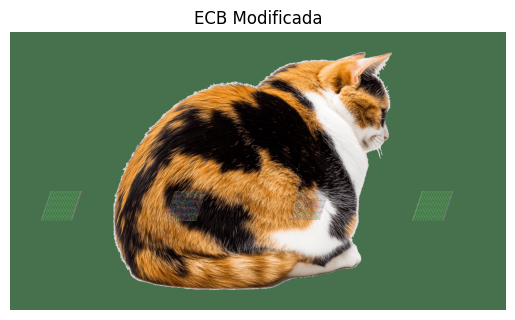

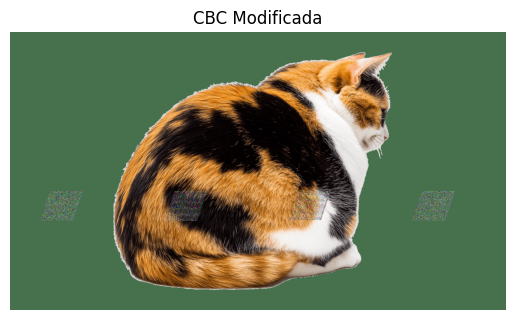

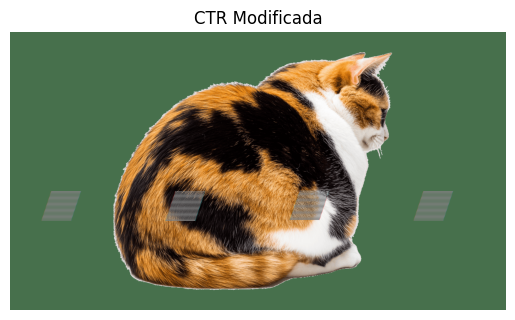

In [15]:
# Visualización después de modificar un byte
show_image('ecb_mod_descifrada.bmp', 'ECB Modificada')
show_image('cbc_mod_descifrada.bmp', 'CBC Modificada')
show_image('ctr_mod_descifrada.bmp', 'CTR Modificada')

### Preguntas de análisis

6. Qué efecto visual tuvo el cambio de un byte en ECB?

En EBC el cambio fue de color, sin embargo, fueron unos cambios de colores con el contraste que ya tiene definida la imagen, entonces perdimos información solo de colores. Pero la integridad en los tres se vio comprometida. Esto ocurre porque, al no haber dependencia entre bloques, bloques de entrada iguales producen bloques cifrados iguales, lo que preserva patrones visibles en la imagen.

7. Qué diferencia observaste en CBC?

En CBC, la alteración de la imagen, bueno, aparte de que, bueno, producimos un pues un efecto como de modificación avalancha, este, indujimos a la imagen a tener como una parte de su estática plasmada en el mensaje descifrado, bueno, en la imagen descifrada, por lo que el gato viene como con marca de agua y el fondo también trae estática. La variación proviene de que cada bloque depende del anterior, lo que rompe la repetición incluso cuando la entrada es similar.

8. Qué diferencia observaste en CTR?

En el caso de CTR, fue como ponerle un parche gris a la imagen, o sea, el fondo tiene parches grises y el gato tiene parches grises. Realmente se perdió prácticamente que toda la información dentro de esa de esas regiones. La ausencia de dependencia entre bloques hace que no exista correlación visible entre regiones similares.

9. Qué modo propagó más el error?

Sin lugar a dudas, el que lo propagó más fue CBC. Observemos cómo la alteración se extiende más allá de la región modificada debido a que cada bloque depende del anterior, lo que introduce cambios adicionales en la imagen descifrada.

10. Qué modo localizó mejor el error?

El modo que mejor localizó el error fue CTR, ya que la modificación permanece contenida en la región afectada debido a la independencia entre bytes, sin propagarse a otras partes de la imagen.

## Parte 7. Intercambio entre compañeros

El compañero intentará descifrar la imagen con los materiales recibidos.

7.1 Descifrado con las llaves del compañero

In [16]:
material_rafa = load_crypto_material('rafa_phisheado.json')
decrypt_bmp('rafa_ecb.bmp','rafa_ecb_descifrada.bmp','ECB',material_rafa)
decrypt_bmp('rafa_cbc.bmp','rafa_cbc_descifrada.bmp','CBC',material_rafa)
decrypt_bmp('rafa_ctr.bmp','rafa_ctr_descifrada.bmp','CTR',material_rafa)

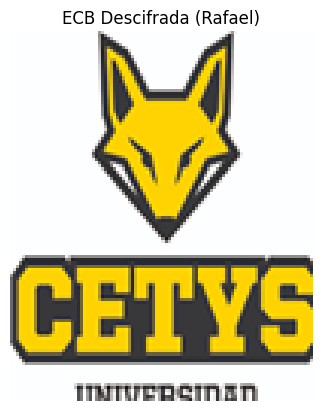

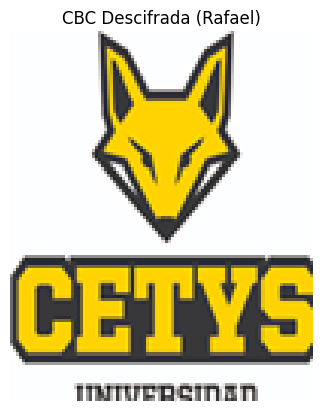

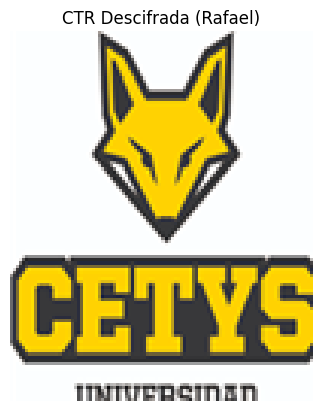

In [17]:
show_image('rafa_ecb_descifrada.bmp', 'ECB Descifrada (Rafael)')
show_image('rafa_cbc_descifrada.bmp', 'CBC Descifrada (Rafael)')
show_image('rafa_ctr_descifrada.bmp', 'CTR Descifrada (Rafael)')

7.2 Prueba adicional: intentar con la llave incorrecta

In [18]:
material_rafa_falso = load_crypto_material('mis_claves_35967.json')
decrypt_bmp('rafa_ecb.bmp','rafa_ecb_descifrada_falsa.bmp','ECB',material_rafa_falso)
decrypt_bmp('rafa_cbc.bmp','rafa_cbc_descifrada_falsa.bmp','CBC',material_rafa_falso)
decrypt_bmp('rafa_ctr.bmp','rafa_ctr_descifrada_falsa.bmp','CTR',material_rafa_falso)

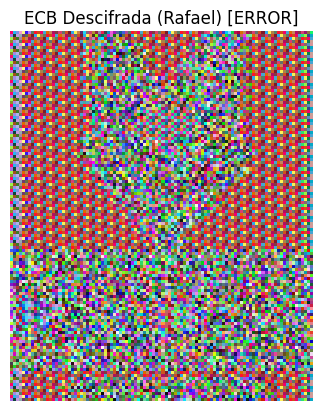

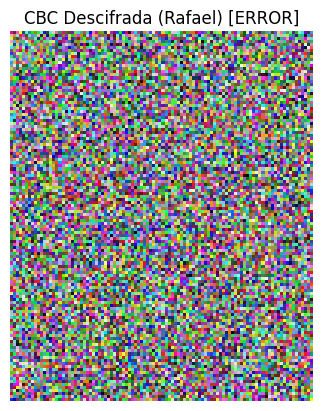

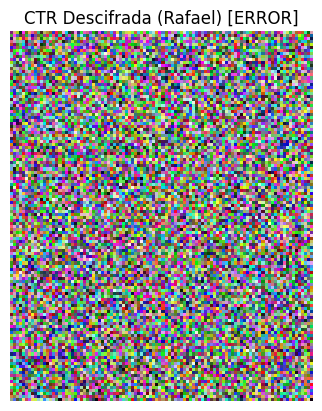

In [19]:
show_image('rafa_ecb_descifrada_falsa.bmp', 'ECB Descifrada (Rafael) [ERROR]')
show_image('rafa_cbc_descifrada_falsa.bmp', 'CBC Descifrada (Rafael) [ERROR]')
show_image('rafa_ctr_descifrada_falsa.bmp', 'CTR Descifrada (Rafael) [ERROR]')

## Parte 8. Conclusión individual
Redactar un párrafo final explicando, con tus propias palabras:

En ECB cada bloque vive aislado. El algoritmo realmente, al tomar los bytes, los 16 bytes y cifrarlos, se mantiene muy simple, pero tiene una consecuencia directa. Si los bloques de entrada son iguales o se parecen, como en el caso del gato y sus parches naranjas y negros, sus salidas también lo serán. Por eso es que en la imagen codificada se veía perfectamente al gato sentado. No es que fallara, solamente no hay ninguna interacción entre los bloques que rompa esa repetición. Entonces ECB conserva su estructura.

CBC introduce una dependencia encadenada. Cada bloque se cifra mezclando con el resultado del bloque anterior, y aunque dos regiones de la imagen sean iguales, el contexto cambia su cifrado, lo que pareciera ser ruido más uniforme. Sin embargo, esa misma dependencia logra que un error se afecte a más de un bloque.

CTR cambia el paradigma en el sentido de que, aunque nunca demandamos bloques, hacemos un flujo y ese flujo se combina con los datos. Cada byte se transforma de manera independiente. Por lo que la imagen cifrada parece puro ruido de estática. Y, más importante, cualquier modificación está plenamente localizada. CTR no propaga y su comportamiento se mantiene independiente entre los datos.

A partir de eso, tenemos que ECB no es recomendable para la información estructurada porque la conserva, o sea, paradójicamente es porque la conserva. Entonces no se oculta y la comprime en bloques cifrados, pero la geometría de la información de atrás está presente, por lo que protege el contenido, pero no el patrón. Y esto ya es suficientemente información para inferir cosas relevantes. Recordemos los ataques de frecuencia y diccionario. Sobre la llave y su uso correcto, aprendí que la llave no es un accesorio, es la condición de reversibilidad de lo que nos va a garantizar que el gato, una vez metido a esta máquina, regrese a nosotros. Sin ella, el cifrado es indistinguible del ruido. Con ella podemos recuperar exactamente a nuestro gato y lo más importante, no es intercambiable ni aproximable. Una llave distinta no produce una versión casi correcta ni una versión alterada, no, o sea, Si ciframos al gato y usamos la llave de otro usuario, no sólo no va a haber gato para nosotros, sino que el gato va a ser ruido. No va a salir un gato blanco, un gato gris, un gato negro, para nada. Y una llave, pues, incorrecta produce un resultado incorrecto, incoherente.

La seguridad no está en el algoritmo, porque este va a ser público, sino en el control de ese material secreto. El experimento de modificar un byte es en realidad el punto que más me tomó tiempo en realizar. Vi que cada modo responde al error de una forma distinta, aplicando el mismo algoritmo responde distinto a las propagaciones, sobre todo en los colores. Y eso expone la estructura interna de cada uno, de modo que en ECB el daño queda contenido en el bloque afectado, no se extiende porque no hay relación entre los bloques. En CBC el error se filtra hacia adelante porque cada bloque depende del anterior. Y en CTR el cambio es, pues, que si altera un byte, solo ese byte se cambia al descifrar, sin efectos negativos colaterales, por eso teníamos un color todo grisáceo en las áreas. Si conectamos todo esto, no probamos nada más los modos, sino... que logramos conocer y observar tres formas distintas de manejar la dependencia entre bloques: inexistente en ECB, encadenada en CBC e independiente en CTR. Esta diferencia en la dependencia explica directamente la presencia de patrones, la uniformidad del ruido y la propagación de errores observada en cada modo.

## Entregables
1. Archivo mis_claves_35967.json
2. Imagen original input.bmp
3. Imágenes cifradas:
ecb.bmp
cbc.bmp
ctr.bmp
4. Imágenes descifradas:
ecb_descifrada.bmp
cbc_descifrada.bmp
ctr_descifrada.bmp
5. Imágenes alteradas y vueltas a descifrar:
ecb_mod.bmp, ecb_mod_descifrada.bmp
cbc_mod.bmp, cbc_mod_descifrada.bmp
ctr_mod.bmp, ctr_mod_descifrada.bmp
6. Respuestas a las preguntas de análisis
7. Conclusión individual

## Criterios de evaluación sugeridos
Criterio | Puntaje
--- | ---
Generación y guardado correcto de llaves y parámetros | 10 pts
Cifrado y descifrado correcto en ECB, CBC y CTR | 20 pts
Análisis visual de diferencias entre modos | 15 pts
Análisis del efecto de modificar un byte | 20 pts
Intercambio con compañero y uso correcto de llaves | 10 pts
Conclusión individual fundamentada | 25 pts
Total | 100 pts

## Nota final
En esta práctica, la llave no fue un valor teórico escrito manualmente, sino un dato generado de forma aleatoria. Cada estudiante tuvo su propia llave, y solo con esa llave fue posible recuperar correctamente la imagen cifrada. Además, al modificar un byte del archivo cifrado, se observó que cada modo de operación reacciona de forma distinta ante errores. Finalmente, al intercambiar archivos y llaves entre ustedes, se comprobó experimentalmente que el cifrado no solo transforma datos, sino que también controla quién puede recuperar la información.
###### ¿Y esta nota final para qué era, profe?